In [5]:
from langchain_core.tools import tool
from config.llm import llm

In [2]:
@tool
def add(a: int, b: int) -> int:
  """Add a and b.
    Args: 
        a: First int
        b: Second int 
  """
  return a + b

In [3]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: First int
        b: Second int
    """
    return a * b

In [4]:
@tool
def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: First int
        b: Second int
    """
    return a / b

In [16]:
tools = [add, multiply, divide]
tools_by_name = {t.name: t for t in tools}
llm_with_tools = llm.bind_tools(tools)

In [6]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator

In [7]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [11]:
from langchain_core.messages import SystemMessage

def llm_call(state: MessagesState):
    """大模型决定：直接回答还是调工具。"""
    return {
        "messages": [
            llm_with_tools.invoke(
                [SystemMessage(content="你是一个计算助手，使用提供的工具来完成计算任务。")]
                + state["messages"]
            )
        ]
    }

In [8]:
from langchain_core.messages import ToolMessage

def tool_node(state: MessagesState):
    """执行工具调用，返回结果。"""
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(
            ToolMessage(content=str(observation), tool_call_id=tool_call["id"])
        )
    return {"messages": result}

In [9]:
from typing import Literal
from langgraph.graph import END

def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    """判断是继续调工具还是结束。"""
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    return END

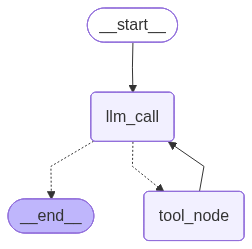

In [13]:
from langgraph.graph import StateGraph, START

# 创建图
graph_builder = StateGraph(MessagesState)

# 添加节点
graph_builder.add_node("llm_call", llm_call)
graph_builder.add_node("tool_node", tool_node)

# 添加边
graph_builder.add_edge(START, "llm_call")        # 入口 → LLM
graph_builder.add_conditional_edges(              # LLM → 工具 or 结束
    "llm_call",
    should_continue,
    ["tool_node", END]
)
graph_builder.add_edge("tool_node", "llm_call")   # 工具 → 回到 LLM

# 编译
agent = graph_builder.compile()


agent

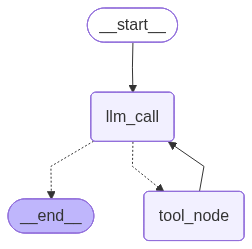

In [14]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [17]:
from langchain_core.messages import HumanMessage

response = agent.invoke(
    {"messages": [HumanMessage(content="3 加 4 等于多少？")]}
)
for msg in response["messages"]:
    msg.pretty_print()

BadRequestError: Error code: 400 - {'error': {'code': '400', 'message': 'Invalid request', 'param': '404 NOT_FOUND "No static resource anthropic/chat/completions."', 'type': ''}, 'request_id': 'f670adaf-7622-4614-91a5-b33b82a4ce48'}